# T14 — The annulus: no side walls, unequal boundaries, and a nullspace

**Cluster E — Part 4, mantle scale.** Requires the container.

Every model in this suite so far has lived in a box. That was the right place
to learn, and it quietly built in an assumption the Earth does not share: a box
has **side walls**, and whatever you impose on them is a fiction. The mantle has
no edges.

A two-dimensional cylindrical annulus removes that fiction, and in doing so
changes three things at once — one geometric, one physical, one numerical. This
notebook is about those three, and it ends with a verification that needs no
reference solution: **the two Nusselt numbers disagree by 81%, and that is the
correct answer.**

## Learning objectives

1. Say what changes when a domain becomes periodic, and what a rotational nullspace is.
2. Plot in a polar projection with pyGMT, and know the two ways `-JP` will trip you.
3. Derive a steady-state check from geometry alone, and use it to confirm convergence.
4. Cost a steady-state calculation honestly, and decide what tolerance you can afford.

## Prerequisites and runtime

* T06 (Blankenbach), T07 (G-ADOPT), T08 (parallelism).
* **Measured runtime: about 9 minutes** — one run to steady state, plus a short
  parallel timing.

In [1]:
# === USER CONFIGURATION ===
NCELLS, NLAYERS = 64, 16       # 128x32 numbers are quoted where they differ
RA = 1e5
TOL = 1e-5                     # the demo uses 1e-7; section 5 is the trade-off
MPI_STEPS = 30                 # fixed-cost run for the parallel timing

In [2]:
import json
import multiprocessing
import os
import subprocess
import sys

import numpy as np
import matplotlib.pyplot as plt

sys.path.insert(0, "..")
from geodynkit import plotting

DRIVER = os.path.join("..", "tools", "gadopt_annulus_case.py")
RMIN, RMAX = 1.22, 2.22


def run(tag, nprocs=1, **kw):
    cmd = ([] if nprocs == 1 else
           ["mpiexec", "--allow-run-as-root", "-n", str(nprocs)])
    cmd += [sys.executable, DRIVER, "--ncells", str(NCELLS),
            "--nlayers", str(NLAYERS), "--ra", str(RA), "--out", f"{tag}.npz"]
    for k, v in kw.items():
        cmd += [f"--{k.replace('_', '-')}", str(v)]
    p = subprocess.run(cmd, capture_output=True, text=True)
    for line in p.stdout.splitlines():
        if line.startswith("RESULT "):
            return json.loads(line[len("RESULT "):])
    raise RuntimeError(f"no result:\n{p.stderr[-1500:]}")

## 1. Three things the annulus changes

**Geometry: the boundaries have different areas.** With $r_{\min} = 1.22$ and
$r_{\max} = 2.22$, circumference scales with radius, so the outer boundary is
$r_{\max}/r_{\min} = 1.82$ times longer than the inner one. Heat entering at the
base spreads over a larger surface on the way out. Hold on to that number; it
comes back in section 4 as a verification.

**Physics: no side walls.** A Cartesian convection cell needs boundary
conditions on four sides, and the two vertical ones are imposed rather than
physical — usually reflecting, which forces the flow to be symmetric about them.
The annulus is periodic by construction, so upwellings and downwellings can sit
wherever the dynamics puts them and can migrate.

**Numerics: a nullspace appears.** A closed box with free-slip walls admits no
rigid-body motion — the walls prevent it. A closed annulus with free-slip
boundaries can **rotate as a rigid body at no cost**, so the discrete Stokes
operator is singular in that direction and the solve will not converge until you
say so:

```python
ns = create_stokes_nullspace(Z, closed=True, rotational=True)
stokes_solver = StokesSolver(..., nullspace=ns, transpose_nullspace=ns,
                             near_nullspace=near_ns)
```

This is the one thing about the annulus that bites immediately, and nothing in
Parts 1 to 3 prepares you for it, because a box never has the freedom.

## 2. Running to steady state

In [3]:
res = run("annulus", tol=TOL, max_steps=4000)
print(f"\nconverged: {res['converged']} after {res['steps']} steps, "
      f"{res['seconds']:.0f} s")
print(f"u_rms   {res['u_rms']:.2f}")
print(f"Nu top  {res['nu_top']:.4f}")
print(f"Nu base {res['nu_base']:.4f}")


converged: True after 1053 steps, 450 s
u_rms   192.96
Nu top  7.6825
Nu base 13.9067


## 3. Plotting an annulus: pyGMT's polar projection

The plotting layer has been the same `field_panel` since T00. It cannot draw
this, because the geometry is not a box — so `geodynkit.plotting` gains one more
function, and it is the last new plotting idiom in the suite.

GMT's polar projection is `-JP`, and it takes the data as $(\theta, r)$ rather
than $(x, y)$. Two things will trip you:

* **the region is angles first** — `theta_min/theta_max/r_min/r_max` — which is
  the opposite order to every Cartesian region you have ever written;
* **the projection width is the diameter of the whole circle**, not the width of
  the annulus. Ask for 13 cm and the ring itself is about 3 cm across. Size for
  the outer radius.

The driver samples onto a regular $(\theta, r)$ grid and resolves velocity into
radial and tangential components while it is there — plotting Cartesian
$(v_x, v_y)$ on a polar projection points every arrow the wrong way except at
$\theta = 0$.

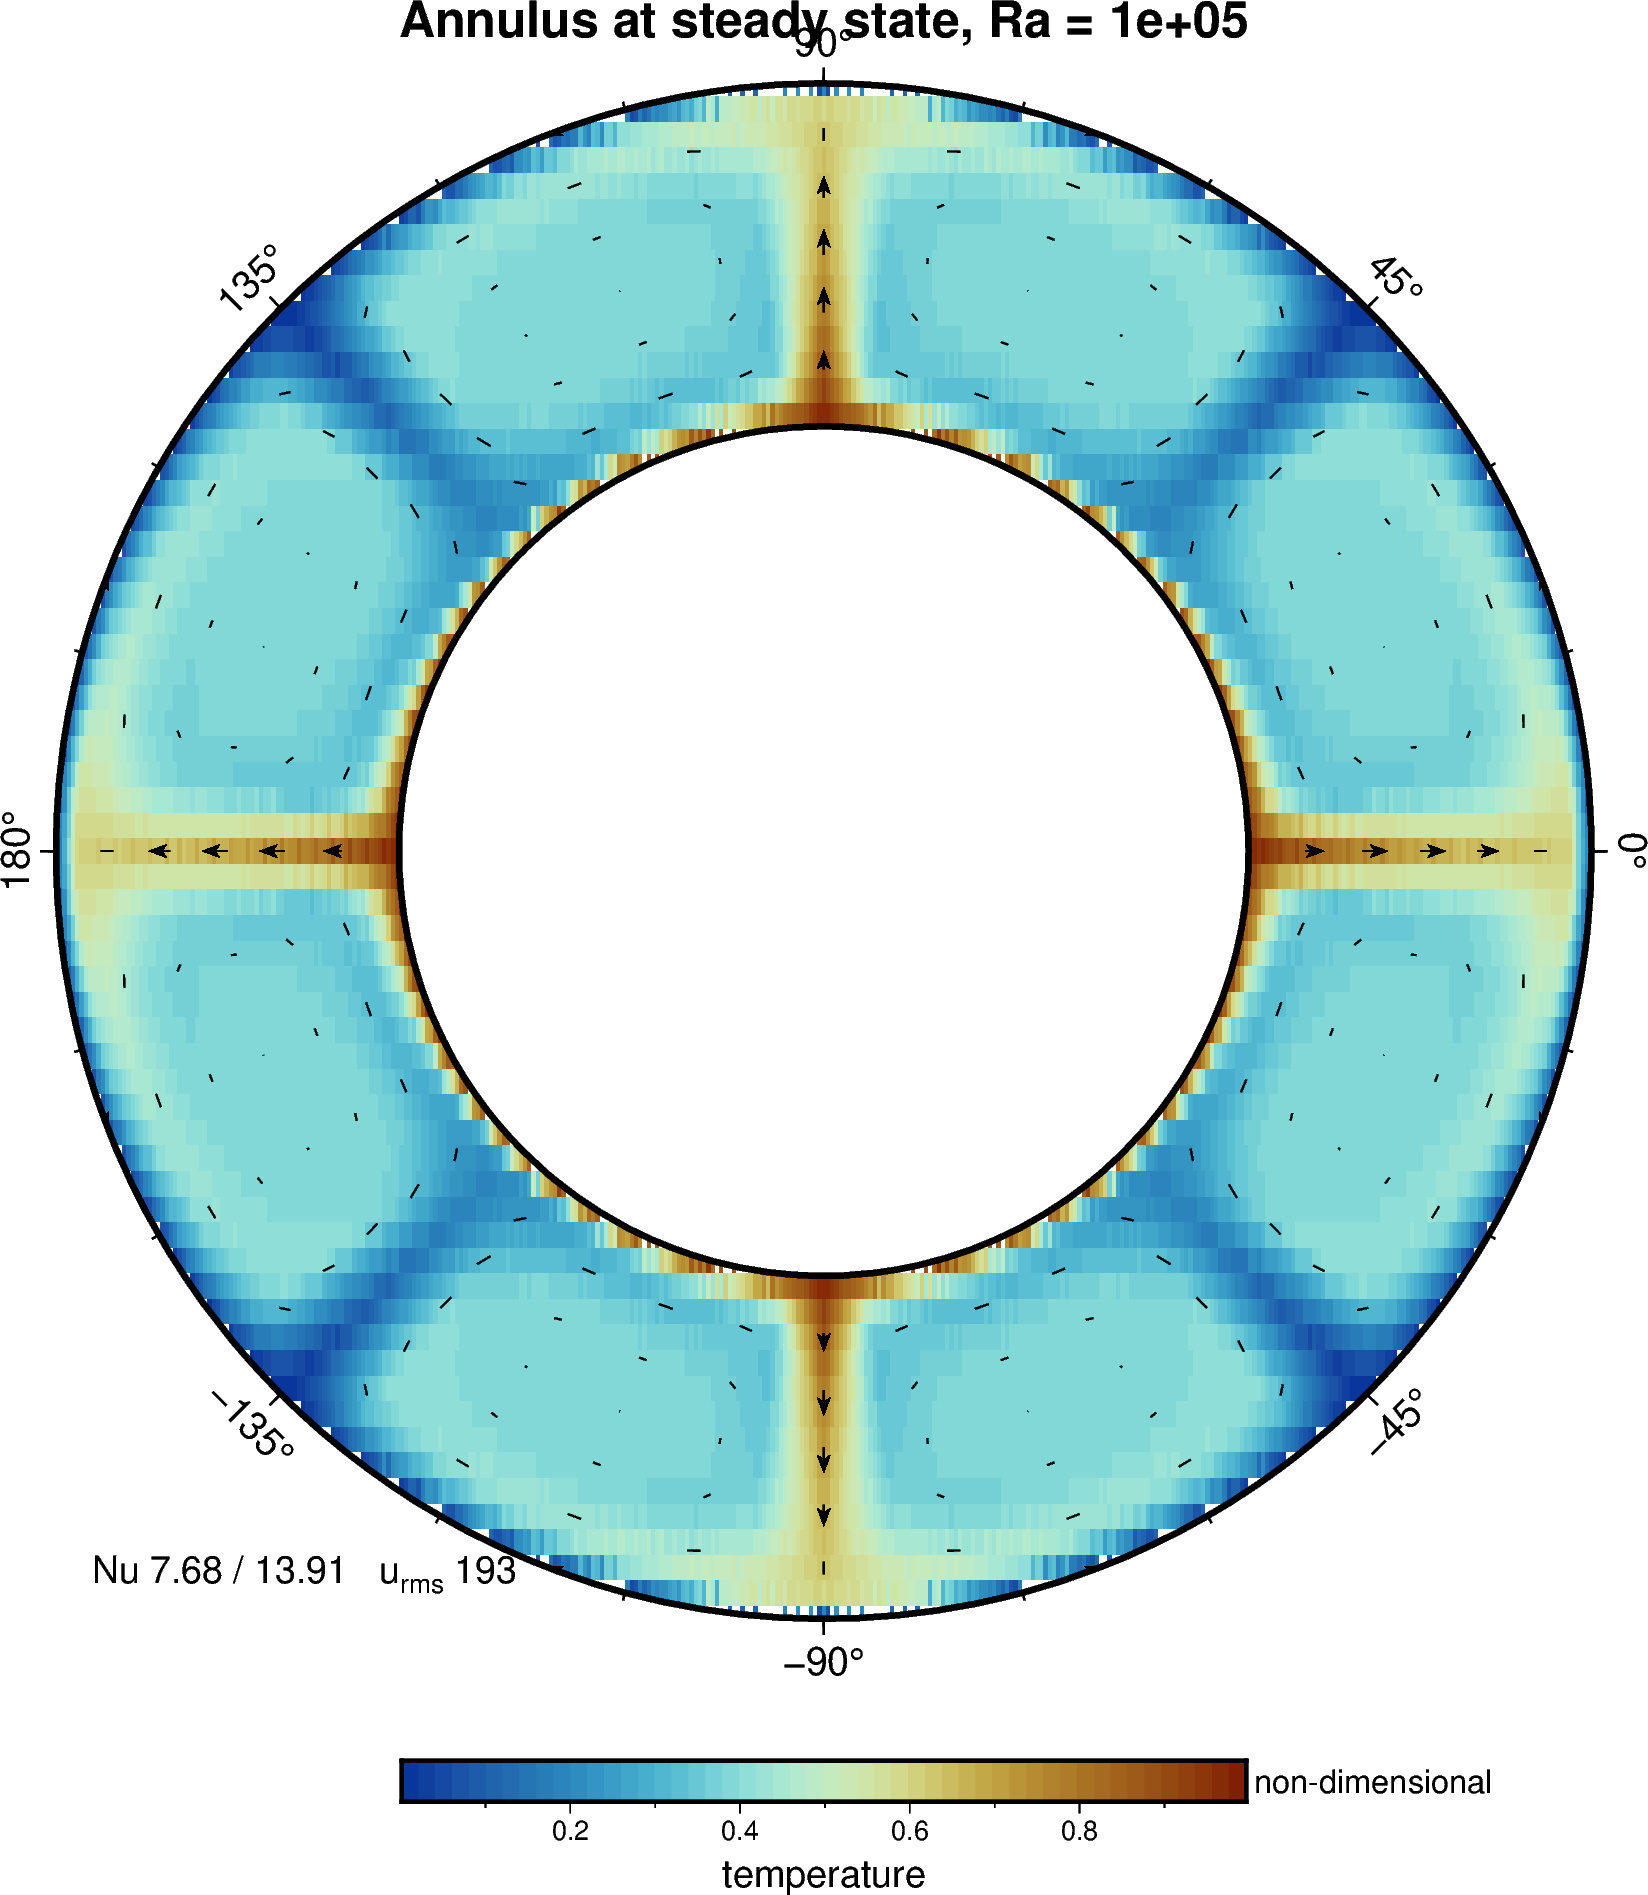

In [4]:
d = np.load("annulus.npz")
fig = plotting.annulus_panel(
    d["temperature"], d["theta_deg"], d["radius"], kind="temperature",
    title=f"Annulus at steady state, Ra = {RA:.0e}",
    label="temperature", unit="non-dimensional",
    u_r=d["u_r"], u_theta=d["u_theta"], every=10, width_cm=13.0, arrow_cm=0.55,
    stamp=f"Nu {res['nu_top']:.2f} / {res['nu_base']:.2f}   "
          f"u@-rms@- {res['u_rms']:.0f}",
)
fig.show()

Four hot plumes rise from the inner boundary with cold downwellings between
them — wavenumber four, which is what the initial perturbation asked for.

Worth watching if you re-run this with a coarser tolerance: at a few hundred
steps the solution has **eight** cells, and the pattern coarsens to four on the
way to steady state. An unconverged annulus does not simply look like a blurred
version of the converged one; it can have a different number of cells. That is
a good reason to distrust a picture taken before the diagnostics settle.

## 4. The verification: two Nusselt numbers that should not agree

In a box at steady state, the heat entering the base equals the heat leaving the
top, and since the two boundaries have the same area the two Nusselt numbers are
equal. Everyone learns to use $\mathrm{Nu}_{\text{top}} =
\mathrm{Nu}_{\text{base}}$ as a convergence check.

**In an annulus that check is wrong.** What balances is the *flux*, and the
boundaries have different areas:

$$\mathrm{Nu}_{\text{base}} \cdot 2\pi r_{\min}
  = \mathrm{Nu}_{\text{top}} \cdot 2\pi r_{\max}
  \quad\Longrightarrow\quad
  \frac{\mathrm{Nu}_{\text{base}}}{\mathrm{Nu}_{\text{top}}}
  = \frac{r_{\max}}{r_{\min}}$$

That is a prediction from geometry alone — no reference solution, no published
table, nothing but the two radii.

In [5]:
print(f"measured  Nu_base / Nu_top = {res['nu_ratio']:.4f}")
print(f"predicted     rmax / rmin  = {res['nu_ratio_expected']:.4f}")
print(f"error                       {100 * res['nu_ratio_error']:.2f}%")

measured  Nu_base / Nu_top = 1.8102
predicted     rmax / rmin  = 1.8197
error                       0.52%


Half a percent, from a run that took nine minutes on one core.

This is the best kind of check: it is derived rather than looked up, it costs
nothing to evaluate, and it fails loudly if the run has not actually converged —
an unconverged annulus is still storing or releasing heat, so its fluxes do not
balance and the ratio is wrong. The table in the next section shows it climbing:
1.000 at the conductive start, 1.677 at 250 steps, 1.810 at convergence.

## 5. What steady state costs

G-ADOPT's demo uses a steady-state tolerance of $10^{-7}$ on the per-step
temperature change. This notebook uses $10^{-5}$, and the difference is not
cosmetic.

In [6]:
h = [(0, 38.98, 1.00, 1.00), (250, 211.16, 7.56, 12.68),
     (1053, res["u_rms"], res["nu_top"], res["nu_base"])]
print(f"{'step':>6} {'u_rms':>9} {'Nu top':>8} {'Nu base':>9} {'ratio':>7}")
for st, u, nt, nb in h:
    print(f"{st:>6} {u:>9.2f} {nt:>8.3f} {nb:>9.3f} {nb / nt:>7.3f}")
print(f"\nexpected ratio {RMAX / RMIN:.3f}")

  step     u_rms   Nu top   Nu base   ratio
     0     38.98    1.000     1.000   1.000
   250    211.16    7.560    12.680   1.677
  1053    192.96    7.683    13.907   1.810

expected ratio 1.820


At 64×16 this run reached $10^{-5}$ in **1053 steps and about 7 minutes**. The
per-step change was still falling steeply at that point, so $10^{-7}$ is
not a hundred times further away — but it is far enough that the demo's default
settings at 128×32 were measured at **over fifty minutes on two cores**, and
projected past an hour and a half.

The judgement to make is not "which tolerance is correct" but **which quantity
you need converged**. The Nusselt ratio in section 4 is already right to half a
percent at $10^{-5}$. If that is what you are after, a hundredfold tighter
tolerance buys nothing. If you want the third digit of $u_{\text{rms}}$, it
might.

## 6. When to reach for cores

T08's rule of thumb was that MPI earns its keep above roughly $10^4$ degrees of
freedom per rank. The annulus is the first case in the suite big enough for the
question to be live.

In [7]:
cores = multiprocessing.cpu_count()
procs = [n for n in (1, 2, 4) if n <= min(4, cores)]
print(f"this machine reports {cores} cores -> timing {procs}")

times = {}
for n in procs:
    r = run(f"annulus_mpi{n}", nprocs=n, tol=0, max_steps=MPI_STEPS)
    times[n] = r["seconds"]
    print(f"  {n} proc: {r['seconds']:6.1f} s for {r['steps']} steps")

if len(times) > 1:
    print(f"\n{'procs':>6} {'speed-up':>9} {'efficiency':>11}")
    for n in procs:
        s = times[procs[0]] / times[n]
        print(f"{n:>6} {s:>9.2f} {s / n:>10.0%}")

this machine reports 2 cores -> timing [1, 2]


  1 proc:   12.4 s for 30 steps


  2 proc:   10.9 s for 30 steps

 procs  speed-up  efficiency
     1      1.00       100%
     2      1.14        57%


Read that with T08's warnings in mind: a single timing is not a measurement, and
on a shared machine the run-to-run spread can be tens of percent. What survives
the noise is whether the trend is worth the trouble at this size.

The honest summary for this suite is that the annulus at 64×16 is *borderline* —
small enough that halo exchange eats much of what extra cores provide. At 128×32
the arithmetic changes, and that is also the resolution at which serial cost
stops being tolerable. Those two facts are not a coincidence: the problem
outgrows one core at about the same size that it outgrows your patience.

## 7. Where this leaves Part 4

The annulus is the geometry that the next notebook needs. T15 replaces the
free-slip top boundary with **plate velocities from a reconstruction** — the
surface stops being a boundary condition you invent and becomes one you import
from a plate model, which is the point at which this suite stops being a
teaching exercise and starts being a research workflow.

## Extend this

* Raise `RA` to 1e6 and re-run at 128×32. Does the cell count change, and does the Nusselt ratio still hold to half a percent?
* Change the initial perturbation's wavenumber from 4 to 3 or 6. Does the steady state remember it, or does it always coarsen to the same number of cells?
* Compute the Nusselt ratio at every recorded step and plot it against the per-step temperature change. Which settles first?
* Try `rmin = 0.55`, the Earth-like core-to-surface ratio, and see how much the geometric factor grows.
* Remove the `rotational=True` from the nullspace and watch what the solver reports. The failure is instructive and immediate.